# TP3 - Vision por Computadora I - CEIA

Encontrar el logotipo de l agaseosa dentro de las imágenes provistas en `Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template`.
1. Obtener una detección del logo en cada imagen sin falsos positivos.
2. Plantear y validar un algorítmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1.
3. Generalizar el algorítmo del ítem 2 para todas las imágenes.

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección.

In [58]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### 1. Obtener la detección del logo en cada imagen sin falsos positivos

Algoritmo planteado:
- construir piramides tanto para la imagen objetivo como para el template, y a cada nivel aplicarle detección de bordes de Canny.
- obtener los puntos descriptores de los bordes de Canny del template.
- para cada nivel de la piramide de la imagen objetivo:
    - para cada nivel de la pirámide del template:
        - aplicar Template Matching entre los niveles de las pirámides y obtener una zona candidato.
            - se aplica Template Matching con las métricas de correlación normalizada y de coeficiente de correlación normalizado, de forma de tener 2 candidatos por combinación de nivel.
        - cropear la zona candidato de los bordes de Canny de la imagen objetivo en su escala original.
        - obtener los puntos descriptores de los bordes de canny zona candidato.
        - si la zona candidato tiene al menos más de la mitad de descriptores que el template.
            - aplicar `knnMatch` y aplicar test de proporción para determinar los matches a guardar.
            - guardar la información del candidato para posterior comparación.
- para todos los candidatos obtenidos, buscar aquel con mayor cociente cantidad de matches y cantidad de descriptores en la imagen cropeada.
- el ganador es la zona donde se encontró el template.


In [59]:
def get_pyramid_canny(base, max_height, sigma=0.33):
    pyramid = []
    base = base.copy()
    while len(pyramid) < max_height and base.shape[0] > 1 and base.shape[1] > 1:
        # compute the median of the single channel pixel intensities
        v = np.median(base)
        # apply automatic Canny edge detection using the computed median
        thr1 = int(max(0, (1.0 - sigma) * v))
        thr2 = int(min(255, (1.0 + sigma) * v))
        
        base_canny = cv.Canny(base, threshold1=thr1, threshold2=thr2)
        pyramid.append(base_canny)
        base = cv.pyrDown(base)

    return pyramid

In [85]:
def detect_template_with_matching(image_path, template_path):
    image = cv.imread(image_path)
    template = cv.imread(template_path, 0)

    # obtengo bordes de Canny de la imagen objetivo y del template 
    image_canny = cv.Canny(image, threshold1=5, threshold2=200)
    template_canny = cv.Canny(template, threshold1=5, threshold2=200)

    # construyo las piramides de la imagen objetivo y el template con Canny en cada nivel
    piramide_template = get_pyramid_canny(template, 3)
    piramide_image = get_pyramid_canny(image, 4)

    # obtengo los descriptores del template
    sift = cv.SIFT_create()
    kp_template, des_template = sift.detectAndCompute(template_canny, None)

    results = []
    for nivel_image, image_i in enumerate(piramide_image):
        for metric in [cv.TM_CCORR_NORMED, cv.TM_CCOEFF_NORMED]:
            for nivel_template, template_i in enumerate(piramide_template):
                w, h = template_i.shape[::-1]
                # verificar que el template no sea más grande que la imagen
                if (
                    template_i.shape[0] < image_i.shape[0] and
                    template_i.shape[1] < image_i.shape[1]
                ):
                    # aplicar Template Matching
                    res = cv.matchTemplate(image_i, template_i, metric)
                    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

                    # obtener las esquinas del candidato
                    top_left = (max_loc[0], max_loc[1])
                    bottom_right = (top_left[0] + w, top_left[1] + h)
                    # escalar las esquinas del candidato 
                    scale_factor = 2**nivel_image
                    top_left_scaled = (max_loc[0] * scale_factor, max_loc[1] * scale_factor)
                    bottom_right_scaled = (top_left_scaled[0] + w*scale_factor, top_left_scaled[1] + h*scale_factor)
                    # cropear los bordes de Canny de la imagen objetivo
                    cropped_img = image_canny[top_left_scaled[1]:bottom_right_scaled[1], top_left_scaled[0]:bottom_right_scaled[0]]

                    # obtener los descriptores de la imagen cropeada
                    kp_img, des_img = sift.detectAndCompute(cropped_img, None)

                    # verificar que se tienen al menos más descriptores que la mitad de los que tiene el template
                    if des_img is not None and des_template is not None and len(des_img) > 0.5 * len(des_template):
                        # computar los matches con knnMatch
                        bf = cv.BFMatcher()
                        matches = bf.knnMatch(des_img, des_template, k=2)

                        # test de proporcion sobre los matches
                        good_matches = []
                        for m, n in matches:
                            if m.distance < 0.8*n.distance:
                                good_matches.append(m)

                        # guardo los resultados
                        results.append({
                            'nivel_image': nivel_image,
                            'nivel_template': nivel_template,
                            'max_val_template_matching': max_val,
                            'top_left': top_left_scaled,
                            'bottom_right': bottom_right_scaled,
                            'len_matches': len(good_matches),
                            'image_descriptors': len(des_img),
                            'template_descriptors': len(des_template),
                        })

    # analizar todos los resultados y guardar aquel con mayor cociente entre
    # cantidad de matches y cantidad de descriptores en la imagen cropeada
    most_matches = 0
    for result in results:
        img_copy = image.copy()
        if result['len_matches'] / result['image_descriptors'] > most_matches:
            most_matches = result['len_matches'] / result['image_descriptors']

            best_top_left = result['top_left']
            best_bottom_right = result['bottom_right']

    # graficamos al ganador    
    cv.rectangle(image, best_top_left, best_bottom_right, (0,255,0), 2)
    plt.imshow(image[:,:,::-1])
    plt.show()

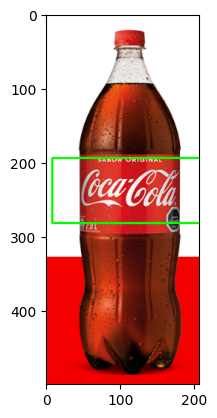

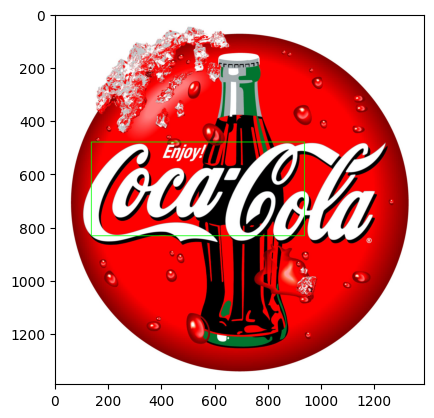

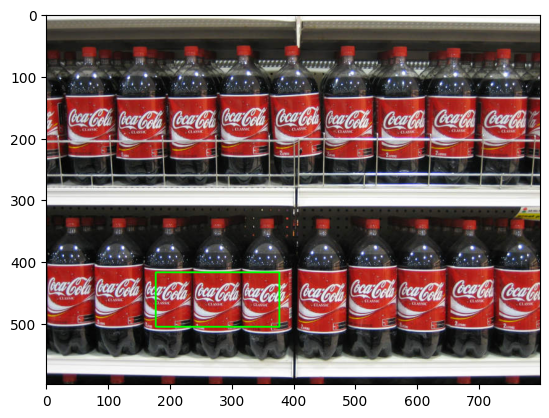

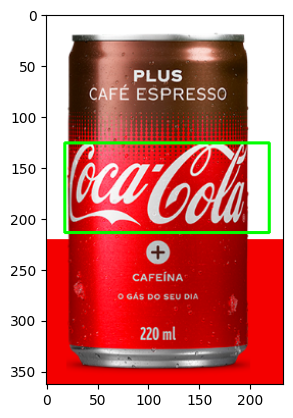

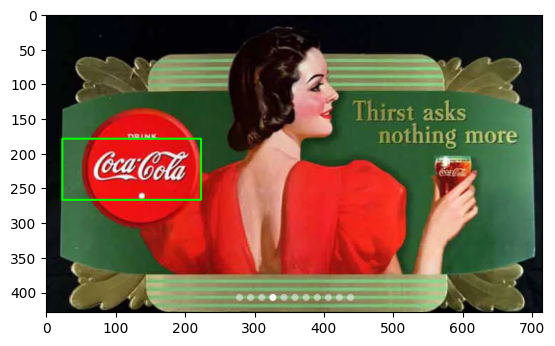

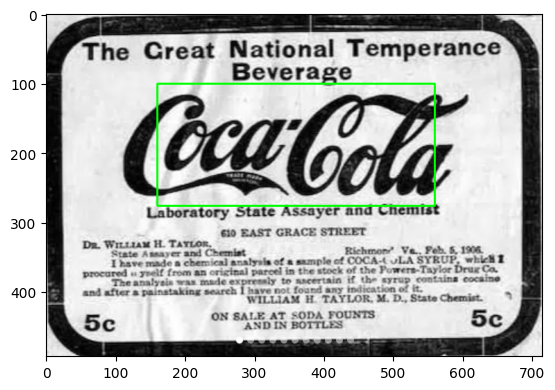

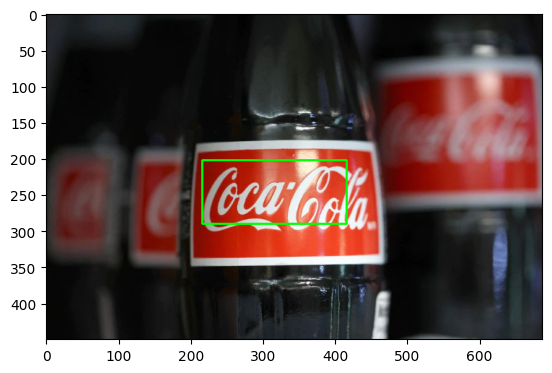

In [87]:
from pathlib import Path

images_paths = [f for f in Path('images').iterdir() if f.is_file()]

for image_path in images_paths:
    detect_template_with_matching(
        image_path = image_path,
        template_path = 'template/pattern.png',
    )

Observamos detección en cada imágen sin falsos positivos. El único detalle negativo es que en la imágen de la góndola de gaseosas, se detecta una zona muy grande y no una zona precisa como se obtendrá en el punto 2.

### 2. Plantear y validar un algorítmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1

Para resolver este punto, gracias a la característica de la imagen objetivo, podemos aplicar un algorítmo más sencillo de detección basado únicamente en template matching.

El algorítmo consiste en:
- computar los bordes de Canny de la imagen objetivo.
- obtener la pirámide del template y aplicar bordes de Canny en cada nivel.
- para cada nivel de la pirámide del template:
    - aplicar template matching entre el nivel y los bordes de Canny de la imagen objetivo.
    - guardar los resultados.
- con el máximo valor de la métrica entre todos los resultados obtenidos, y computar un valor absoluto de umbral en función al argumento `thr`.
- para el resultado de cada nivel:
    - obtener los puntos con métrica mayor al umbral definido.
    - buscar los puntos cercanos y descartar todos menos 1. (De esta forma evitamos tener múltiples detecciones de 1 instancia)

In [92]:
from scipy.signal import vectorstrength
def match_multiple(image_path, template_path, metric=cv.TM_CCOEFF_NORMED, thr=0.8):
    image = cv.imread(image_path)
    template = cv.imread(template_path, 0)

    image_canny = cv.Canny(image, threshold1=5, threshold2=200)

    piramide_template = get_pyramid_canny(template, 3)

    res_levels = []
    best_val = 0
    # for nivel_image, image_i in enumerate(piramide_image):
    for nivel_template, template_i in enumerate(piramide_template):
        w, h = template_i.shape[::-1]
        if (
            template_i.shape[0] < image_canny.shape[0] and
            template_i.shape[1] < image_canny.shape[1]
        ):
            # res = cv.matchTemplate(image_i, template_i, metric)
            res = cv.matchTemplate(image_canny, template_i, metric)
            _, max_val, _, _ = cv.minMaxLoc(res)

            if max_val > best_val:
                best_val = max_val

            res_levels.append({
                'max_val': max_val,
                'res': res
            })


    global_thr = thr * best_val
    for level in res_levels:
        res = level['res']
        loc = np.where(res >= global_thr)
        points = []
        for point in zip(*loc[::-1]):
            bad_point = False
            for p in points:
                d_points = np.sqrt((point[0]-p[0])**2 + (point[1]-p[1])**2)
                if d_points < 20:
                    bad_point = True
            if not bad_point:
                points.append(point)
                cv.rectangle(image, point, (point[0] + w, point[1] + h), (0,255,0), 2)

    plt.imshow(image[:,:,::-1])
    plt.show()


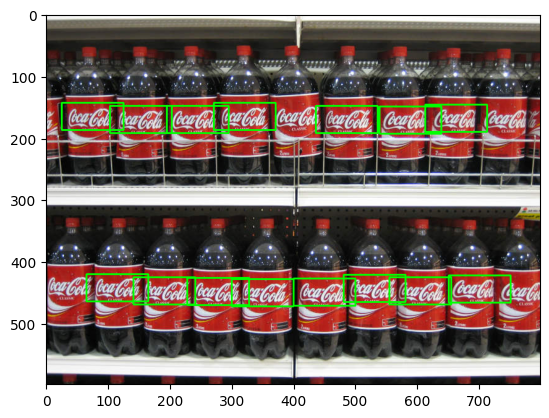

In [93]:
match_multiple('images/coca_multi.png', 'template/pattern.png', thr=0.5)

Observamos una detección de 15/19 ($\approx$ 79%) ocurrencias del logo de Coca-Cola.

### 3. Generalizar el algorítmo del item 2 para todas las imágenes

Si aplicamos el algorítmo del punto anterior a todas las imágenes, obtenemos resultados bastante pobres. Esto tiene sentido ya que el algorítmo para detectar matches es mucho más simple que en el punto 1. Por una cuestión de tiempos no llegué a implementar el algorítmo para este punto, pero mi idea sería realizar un algorítmo que genere las coincidencias en función de una métrica de la cantidad de coincidencia de puntos característicos, a partir de candidatos seleccionados con template matching.

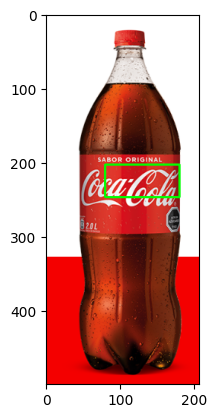

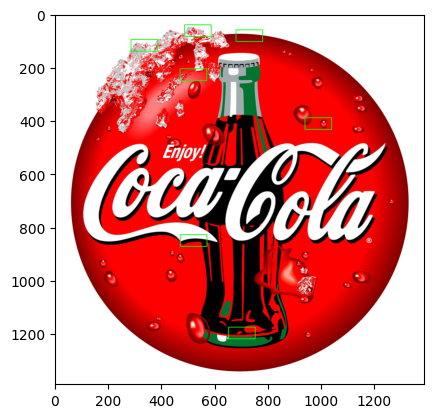

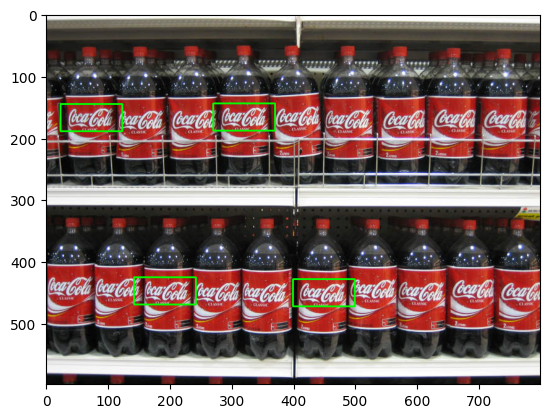

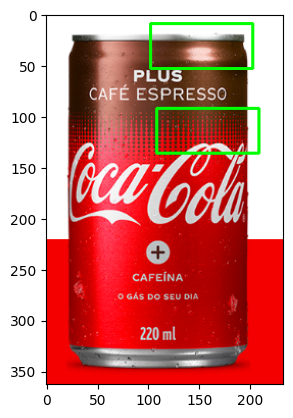

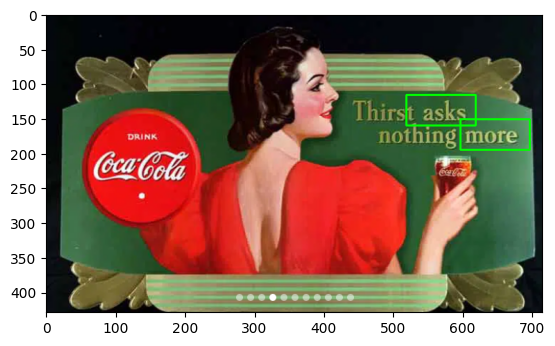

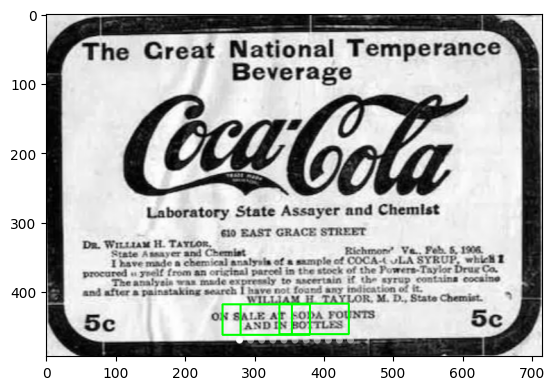

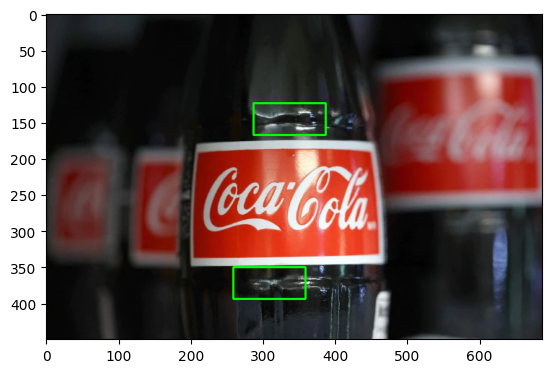

In [94]:
from pathlib import Path
images_paths = [f for f in Path('images').iterdir() if f.is_file()]

for image_path in images_paths:
    match_multiple(image_path, 'template/pattern.png', thr=0.9)
